<a href="https://colab.research.google.com/github/Dandyeriametor/Activity/blob/main/Assignment_12_Neural_Network_and_Deep_Learning_Basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 12: Neural Network and Deep Learning Basics

Author: Dandy Eriametor

Business Intelligence Analyst

Student Number: DE111080

# Feedforward Neural Network for Image Classification (Fashion-MNIST)


In [5]:

#@title Quickstart (Colab)
import sys, platform
print("Python:", sys.version)
print("Platform:", platform.platform())

import tensorflow as tf, sklearn, numpy as np, matplotlib
print("TensorFlow:", tf.__version__)
print("scikit-learn:", sklearn.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)


Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.105+-x86_64-with-glibc2.35
TensorFlow: 2.19.0
scikit-learn: 1.6.1
NumPy: 2.0.2
Matplotlib: 3.10.0



## Overview
Train and evaluate a **feedforward (Dense-only)** neural network on **Fashion-MNIST**.


In [6]:
# Import all the required Libraries
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

np.random.seed(42)
tf.random.set_seed(42)



## 1) Dataset: Fashion-MNIST


In [7]:

(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]
print("Train:", x_train.shape, "Test:", x_test.shape)


Train: (60000, 28, 28) Test: (10000, 28, 28)


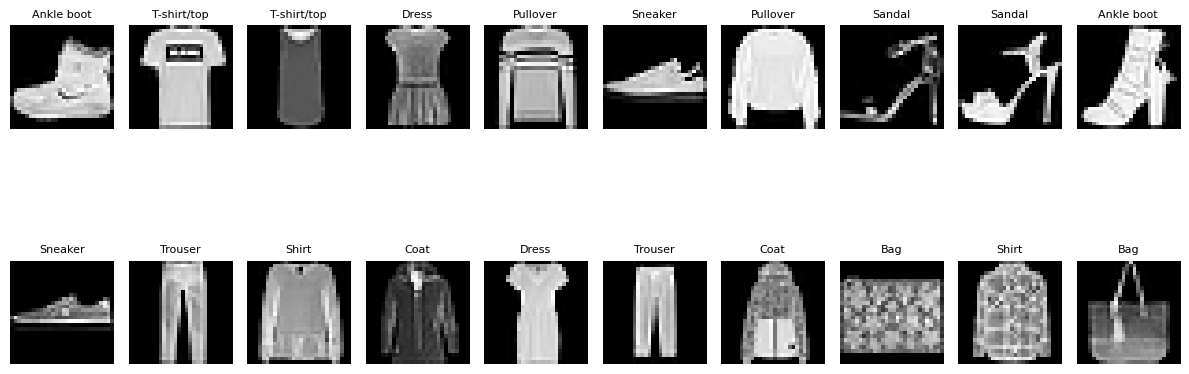

In [8]:
# Visualize samples (2 per class)
plt.figure(figsize=(12, 6))
shown = {c:0 for c in range(10)}
rows, cols = 2, 10
idx = 1
for img, label in zip(x_train, y_train):
    if all(v >= rows for v in shown.values()):
        break
    if shown[label] < rows:
        plt.subplot(rows, cols, idx)
        plt.imshow(img, cmap='gray')
        plt.title(class_names[label], fontsize=8)
        plt.axis('off')
        shown[label] += 1
        idx += 1
plt.tight_layout()
plt.show()



## 2) Preprocessing


In [9]:

x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

num_classes = 10
y_train_oh = to_categorical(y_train, num_classes)
y_test_oh  = to_categorical(y_test, num_classes)

print(x_train_norm.shape, y_train_oh.shape, x_test_norm.shape, y_test_oh.shape)


(60000, 28, 28) (60000, 10) (10000, 28, 28) (10000, 10)



## 3) Baseline Feedforward Model


In [10]:

def build_mlp(input_shape=(28,28), num_classes=10, hidden_units=(512, 256), dropout_rate=0.2):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(hidden_units[0], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[1], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

baseline_model = build_mlp()
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 - 12s - 14ms/step - accuracy: 0.8098 - loss: 0.5257 - val_accuracy: 0.8450 - val_loss: 0.4145
Epoch 2/15
844/844 - 12s - 14ms/step - accuracy: 0.8560 - loss: 0.3939 - val_accuracy: 0.8600 - val_loss: 0.3759
Epoch 3/15
844/844 - 11s - 13ms/step - accuracy: 0.8692 - loss: 0.3559 - val_accuracy: 0.8695 - val_loss: 0.3593
Epoch 4/15
844/844 - 10s - 12ms/step - accuracy: 0.8748 - loss: 0.3380 - val_accuracy: 0.8712 - val_loss: 0.3510
Epoch 5/15
844/844 - 10s - 12ms/step - accuracy: 0.8805 - loss: 0.3193 - val_accuracy: 0.8763 - val_loss: 0.3325
Epoch 6/15
844/844 - 11s - 13ms/step - accuracy: 0.8850 - loss: 0.3050 - val_accuracy: 0.8742 - val_loss: 0.3396
Epoch 7/15
844/844 - 10s - 12ms/step - accuracy: 0.8879 - loss: 0.2976 - val_accuracy: 0.8777 - val_loss: 0.3333
Epoch 8/15
844/844 - 11s - 13ms/step - accuracy: 0.8930 - loss: 0.2866 - val_accuracy: 0.8835 - val_loss: 0.3233
Epoch 9/15
844/844 - 9s - 11ms/step - accuracy: 0.8961 - loss: 0.2742 - val_accuracy: 0.8815 - v

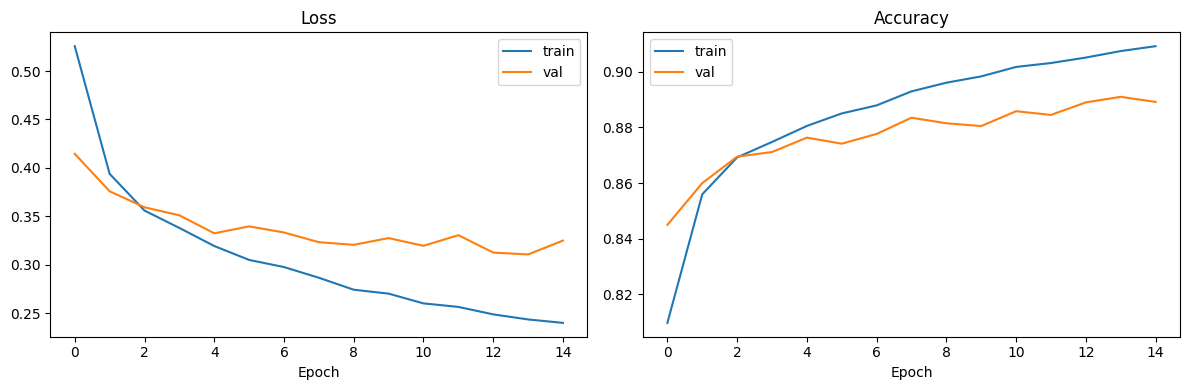

In [11]:
history_baseline = baseline_model.fit(
    x_train_norm, y_train_oh,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    verbose=2
)

# Plot curves
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history_baseline.history['loss']); plt.plot(history_baseline.history['val_loss']); plt.title('Loss'); plt.xlabel('Epoch'); plt.legend(['train','val'])
plt.subplot(1,2,2); plt.plot(history_baseline.history['accuracy']); plt.plot(history_baseline.history['val_accuracy']); plt.title('Accuracy'); plt.xlabel('Epoch'); plt.legend(['train','val'])
plt.tight_layout(); plt.show()



## 4) Evaluation


Baseline — Accuracy: 0.8838 | Precision: 0.8851 | Recall: 0.8838 | F1: 0.8830

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.85      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.84      0.75      0.80      1000
       Dress       0.85      0.91      0.88      1000
        Coat       0.74      0.87      0.80      1000
      Sandal       0.94      0.98      0.96      1000
       Shirt       0.76      0.66      0.71      1000
     Sneaker       0.93      0.95      0.94      1000
         Bag       0.98      0.97      0.98      1000
  Ankle boot       0.98      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



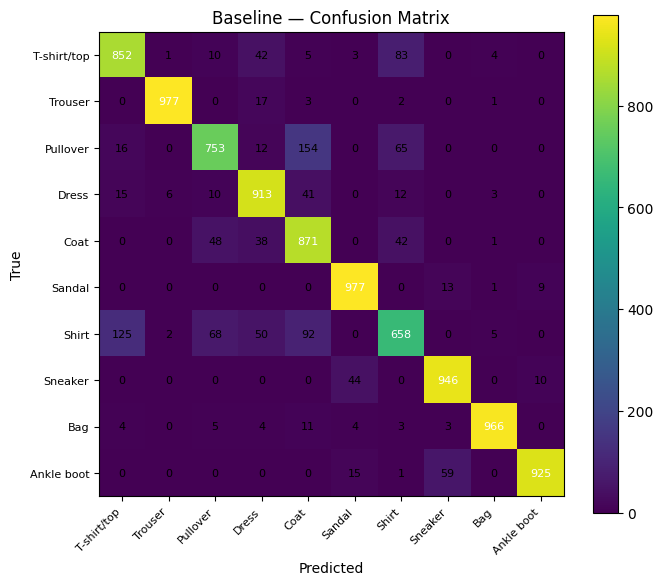

In [12]:
def evaluate_model(model, x_test, y_test_oh, class_names, prefix="Model"):
    y_prob = model.predict(x_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = np.argmax(y_test_oh, axis=1)

    acc = np.mean(y_pred == y_true)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print(f"{prefix} — Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}\n")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation='nearest')
    plt.title(f'{prefix} — Confusion Matrix'); plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right', fontsize=8)
    plt.yticks(ticks, class_names, fontsize=8)
    plt.xlabel('Predicted'); plt.ylabel('True')

    thresh = cm.max() * 0.6
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > thresh else 'black', fontsize=8)
    plt.tight_layout(); plt.show()

baseline_metrics = evaluate_model(baseline_model, x_test_norm, y_test_oh, class_names, prefix="Baseline")



## 5) MLP with On-the-Fly Data Augmentation


In [13]:
def build_augmented_mlp(input_shape=(28,28,1), num_classes=10, hidden_units=(512, 256), dropout_rate=0.2):
    aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomTranslation(0.05, 0.05),
    ])
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),
        aug,
        layers.Flatten(),
        layers.Dense(hidden_units[0], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(hidden_units[1], activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

x_train_3d = np.expand_dims(x_train, -1)
x_test_3d  = np.expand_dims(x_test, -1)

aug_model = build_augmented_mlp()
aug_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_1 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
844/844 - 15s - 18ms/step - accuracy: 0.8239 - loss: 0.4713 - val_accuracy: 0.8438 - val_loss: 0.3993
Epoch 2/15
844/844 - 16s - 19ms/step - accuracy: 0.8274 - loss: 0.4658 - val_accuracy: 0.8463 - val_loss: 0.4018
Epoch 3/15
844/844 - 15s - 18ms/step - accuracy: 0.8266 - loss: 0.4597 - val_accuracy: 0.8460 - val_loss: 0.4002
Epoch 4/15
844/844 - 15s - 18ms/step - accuracy: 0.8272 - loss: 0.4632 - val_accuracy: 0.8440 - val_loss: 0.4002
Epoch 5/15
844/844 - 22s - 26ms/step - accuracy: 0.8284 - loss: 0.4604 - val_accuracy: 0.8380 - val_loss: 0.4139
Epoch 6/15
844/844 - 16s - 18ms/step - accuracy: 0.8322 - loss: 0.4520 - val_accuracy: 0.8490 - val_loss: 0.3886
Epoch 7/15
844/844 - 15s - 18ms/step - accuracy: 0.8323 - loss: 0.4532 - val_accuracy: 0.8475 - val_loss: 0.3995
Epoch 8/15
844/844 - 15s - 18ms/step - accuracy: 0.8337 - loss: 0.4517 - val_accuracy: 0.8437 - val_loss: 0.4036
Epoch 9/15
844/844 - 16s - 19ms/step - accuracy: 0.8309 - loss: 0.4512 - val_accuracy: 0.8433 - 

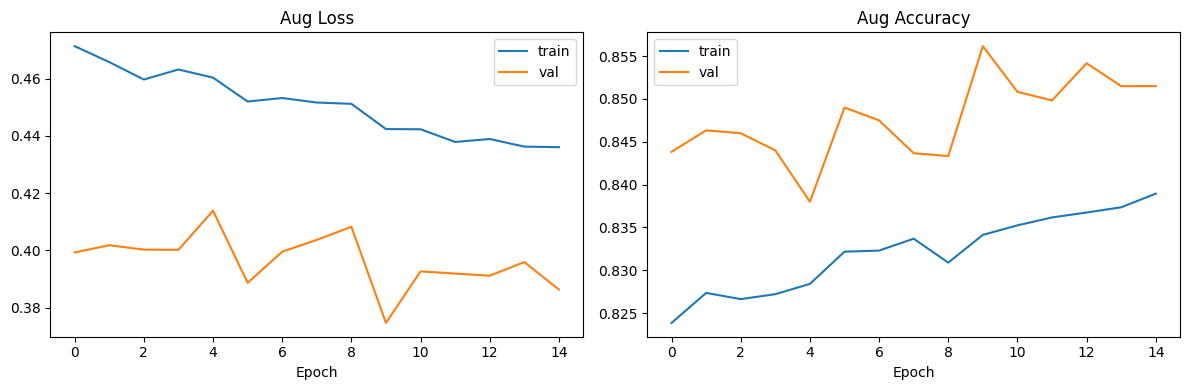

Augmented — Accuracy: 0.1000 | Precision: 0.0100 | Recall: 0.1000 | F1: 0.0182

              precision    recall  f1-score   support

 T-shirt/top       0.00      0.00      0.00      1000
     Trouser       0.00      0.00      0.00      1000
    Pullover       0.00      0.00      0.00      1000
       Dress       0.00      0.00      0.00      1000
        Coat       0.00      0.00      0.00      1000
      Sandal       0.10      1.00      0.18      1000
       Shirt       0.00      0.00      0.00      1000
     Sneaker       0.00      0.00      0.00      1000
         Bag       0.00      0.00      0.00      1000
  Ankle boot       0.00      0.00      0.00      1000

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



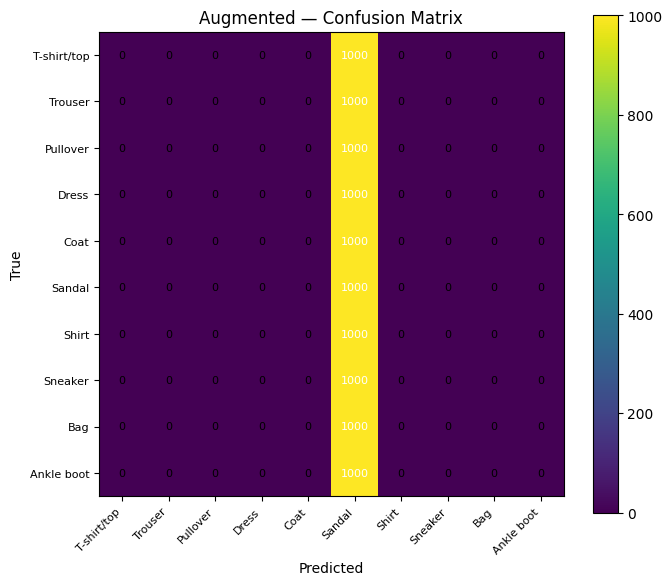

In [16]:
history_aug = aug_model.fit(
    x_train_3d, y_train_oh,
    validation_split=0.1,
    epochs=15,
    batch_size=64,
    verbose=2
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(history_aug.history['loss']); plt.plot(history_aug.history['val_loss']); plt.title('Aug Loss'); plt.xlabel('Epoch'); plt.legend(['train','val'])
plt.subplot(1,2,2); plt.plot(history_aug.history['accuracy']); plt.plot(history_aug.history['val_accuracy']); plt.title('Aug Accuracy'); plt.xlabel('Epoch'); plt.legend(['train','val'])
plt.tight_layout(); plt.show()

aug_metrics = evaluate_model(aug_model, x_test_3d/255.0, y_test_oh, class_names, prefix="Augmented")



## 6) Simple Hyperparameter Variant


Epoch 1/12
844/844 - 8s - 10ms/step - accuracy: 0.7816 - loss: 0.6120 - val_accuracy: 0.8388 - val_loss: 0.4528
Epoch 2/12
844/844 - 5s - 6ms/step - accuracy: 0.8406 - loss: 0.4384 - val_accuracy: 0.8580 - val_loss: 0.3801
Epoch 3/12
844/844 - 7s - 8ms/step - accuracy: 0.8552 - loss: 0.3976 - val_accuracy: 0.8657 - val_loss: 0.3629
Epoch 4/12
844/844 - 6s - 8ms/step - accuracy: 0.8658 - loss: 0.3693 - val_accuracy: 0.8685 - val_loss: 0.3519
Epoch 5/12
844/844 - 7s - 8ms/step - accuracy: 0.8684 - loss: 0.3563 - val_accuracy: 0.8765 - val_loss: 0.3371
Epoch 6/12
844/844 - 5s - 6ms/step - accuracy: 0.8747 - loss: 0.3376 - val_accuracy: 0.8760 - val_loss: 0.3326
Epoch 7/12
844/844 - 7s - 8ms/step - accuracy: 0.8789 - loss: 0.3291 - val_accuracy: 0.8755 - val_loss: 0.3301
Epoch 8/12
844/844 - 6s - 7ms/step - accuracy: 0.8816 - loss: 0.3187 - val_accuracy: 0.8753 - val_loss: 0.3326
Epoch 9/12
844/844 - 6s - 7ms/step - accuracy: 0.8856 - loss: 0.3144 - val_accuracy: 0.8815 - val_loss: 0.3269


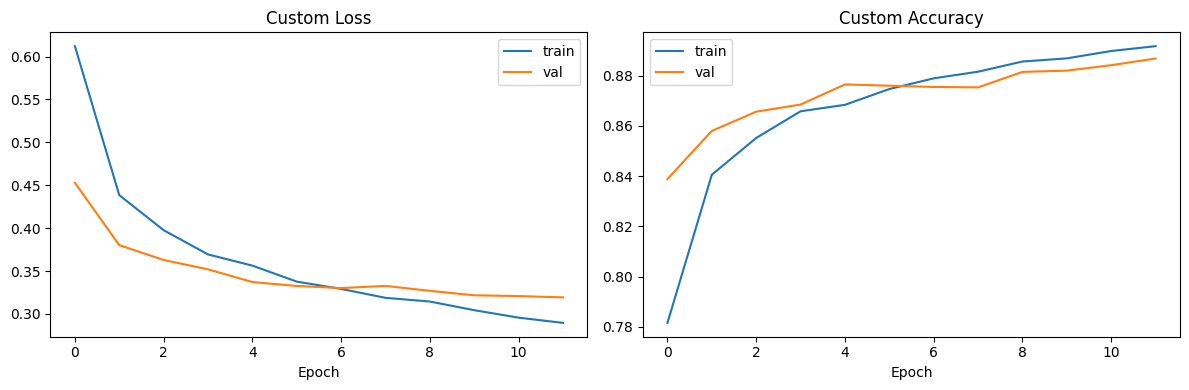

Custom — Accuracy: 0.8812 | Precision: 0.8810 | Recall: 0.8812 | F1: 0.8796

              precision    recall  f1-score   support

 T-shirt/top       0.80      0.88      0.84      1000
     Trouser       0.97      0.97      0.97      1000
    Pullover       0.80      0.78      0.79      1000
       Dress       0.87      0.90      0.88      1000
        Coat       0.75      0.84      0.79      1000
      Sandal       0.96      0.98      0.97      1000
       Shirt       0.76      0.60      0.67      1000
     Sneaker       0.93      0.96      0.95      1000
         Bag       0.98      0.97      0.97      1000
  Ankle boot       0.98      0.94      0.96      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



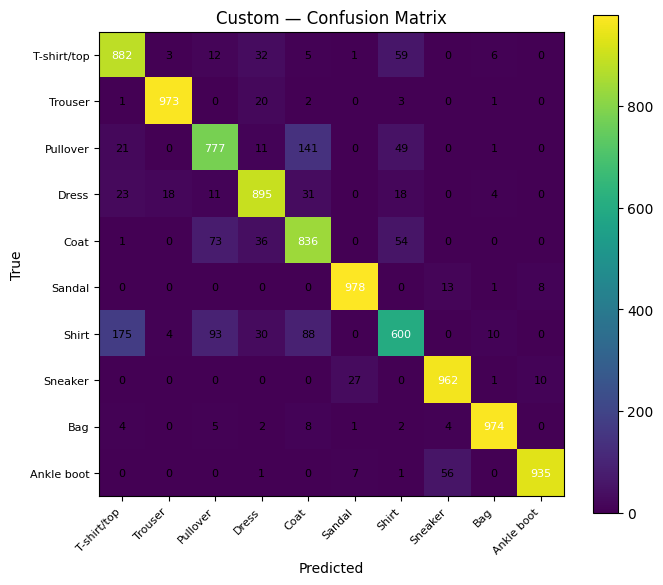

In [15]:

def build_mlp_custom(input_shape=(28,28), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-4),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

custom_model = build_mlp_custom()
hist_custom = custom_model.fit(
    x_train_norm, y_train_oh,
    validation_split=0.1,
    epochs=12,
    batch_size=64,
    verbose=2
)

plt.figure(figsize=(12,4))
plt.subplot(1,2,1); plt.plot(hist_custom.history['loss']); plt.plot(hist_custom.history['val_loss']); plt.title('Custom Loss'); plt.xlabel('Epoch'); plt.legend(['train','val'])
plt.subplot(1,2,2); plt.plot(hist_custom.history['accuracy']); plt.plot(hist_custom.history['val_accuracy']); plt.title('Custom Accuracy'); plt.xlabel('Epoch'); plt.legend(['train','val'])
plt.tight_layout(); plt.show()

custom_metrics = evaluate_model(custom_model, x_test_norm, y_test_oh, class_names, prefix="Custom")
